<a href="https://colab.research.google.com/github/kikianggreani-glitch/UTS-/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
print("=" * 60)
print("  KLASIFIKASI WINE QUALITY - K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

df_train = pd.read_csv('https://drive.google.com/uc?id=14smuGADaoB6tTdDZ-82viYJv6uKi1LAt')
df_test  = pd.read_csv('https://drive.google.com/uc?id=1Fc2SefcyCSfYQvdIf9DJKAy6aAuD2lCM')

print(f"\n[INFO] Data Training : {df_train.shape[0]} baris, {df_train.shape[1]} kolom")
print(f"[INFO] Data Testing  : {df_test.shape[0]} baris, {df_test.shape[1]} kolom")

  KLASIFIKASI WINE QUALITY - K-NEAREST NEIGHBORS (KNN)

[INFO] Data Training : 857 baris, 13 kolom
[INFO] Data Testing  : 286 baris, 12 kolom


In [ ]:
# ─────────────────────────────────────────
# 2. EKSPLORASI DATA TRAINING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  EKSPLORASI DATA TRAINING")
print("=" * 60)

print("\n[INFO] 5 Baris Pertama:")
print(df_train.head())

print("\n[INFO] Statistik Deskriptif:")
print(df_train.describe().round(3))

print("\n[INFO] Missing Values:")
print(df_train.isnull().sum())

print("\n[INFO] Distribusi Label (quality):")
print(df_train['quality'].value_counts().sort_index().to_string())


  EKSPLORASI DATA TRAINING

[INFO] 5 Baris Pertama:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0    

In [ ]:
# ─────────────────────────────────────────
# 3. PERSIAPAN FITUR DAN TARGET
# ─────────────────────────────────────────
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]

X_train = df_train[feature_cols]
y_train = df_train['quality']
X_test  = df_test[feature_cols]
id_test = df_test['Id']

print(f"\n[INFO] Fitur digunakan : {len(feature_cols)} fitur")
print(f"[INFO] Kelas unik      : {sorted(y_train.unique())}")


[INFO] Fitur digunakan : 11 fitur
[INFO] Kelas unik      : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [ ]:
# ─────────────────────────────────────────
# CEK MISSING VALUE DATA TESTING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  CEK MISSING VALUE - DATA TESTING")
print("=" * 60)

print("\n[INFO] Missing Values pada Data Testing:")
missing_test = df_test.isnull().sum()
print(missing_test)

print(f"\n[INFO] Total missing value : {missing_test.sum()}")

if missing_test.sum() == 0:
    print("[INFO] Tidak ada missing value pada data testing. ✅")
else:
    print("[WARNING] Ditemukan missing value! Melakukan imputasi dengan median data training...")

    for col in feature_cols:
        if df_test[col].isnull().sum() > 0:
            median_val = X_train[col].median()
            df_test[col].fillna(median_val, inplace=True)
            print(f"  - Kolom '{col}' diimputasi dengan median training: {median_val:.4f}")

    # Update X_test setelah imputasi
    X_test = df_test[feature_cols]

    print("\n[INFO] Cek ulang setelah imputasi:")
    print(df_test[feature_cols].isnull().sum())
    print("[INFO] Imputasi selesai. ✅")


  CEK MISSING VALUE - DATA TESTING

[INFO] Missing Values pada Data Testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

[INFO] Total missing value : 0
[INFO] Tidak ada missing value pada data testing. ✅


In [ ]:
# ─────────────────────────────────────────
# 4. NORMALISASI (WAJIB untuk KNN)
#    KNN sangat sensitif terhadap skala fitur
# ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n[INFO] Normalisasi dengan StandardScaler selesai.")
print("[INFO] Catatan: Normalisasi WAJIB untuk KNN karena berbasis jarak.")


[INFO] Normalisasi dengan StandardScaler selesai.
[INFO] Catatan: Normalisasi WAJIB untuk KNN karena berbasis jarak.


In [ ]:
# ─────────────────────────────────────────
# 5. MENCARI NILAI K OPTIMAL
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  MENCARI NILAI K OPTIMAL")
print("=" * 60)
print("\n[INFO] Menguji K dari 1 sampai 30...")

k_range   = range(1, 31)
k_scores  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

best_k     = k_range[np.argmax(k_scores)]
best_k_acc = max(k_scores)

print(f"\n  Nilai K terbaik  : K = {best_k}")
print(f"  CV Accuracy      : {best_k_acc * 100:.2f}%")
print(f"\n  Skor CV per K:")
for k, score in zip(k_range, k_scores):
    marker = " ◄ TERBAIK" if k == best_k else ""
    print(f"    K={k:2d} : {score*100:.2f}%{marker}")


  MENCARI NILAI K OPTIMAL

[INFO] Menguji K dari 1 sampai 30...

  Nilai K terbaik  : K = 29
  CV Accuracy      : 57.64%

  Skor CV per K:
    K= 1 : 56.94%
    K= 2 : 54.03%
    K= 3 : 52.27%
    K= 4 : 53.44%
    K= 5 : 54.14%
    K= 6 : 55.54%
    K= 7 : 54.60%
    K= 8 : 54.84%
    K= 9 : 53.56%
    K=10 : 55.54%
    K=11 : 55.54%
    K=12 : 55.89%
    K=13 : 55.89%
    K=14 : 55.77%
    K=15 : 55.89%
    K=16 : 56.47%
    K=17 : 56.47%
    K=18 : 56.59%
    K=19 : 56.82%
    K=20 : 57.06%
    K=21 : 56.12%
    K=22 : 56.71%
    K=23 : 55.77%
    K=24 : 56.47%
    K=25 : 56.24%
    K=26 : 56.24%
    K=27 : 56.82%
    K=28 : 57.52%
    K=29 : 57.64% ◄ TERBAIK
    K=30 : 57.17%


In [ ]:
# ─────────────────────────────────────────
# 6. TRAINING MODEL KNN (K optimal)
# ─────────────────────────────────────────
print(f"\n[INFO] Melatih model KNN dengan K={best_k}...")

knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',   # default = Euclidean distance (p=2)
    weights='uniform'     # semua tetangga bobotnya sama
)

knn_model.fit(X_train_scaled, y_train)
print("[INFO] Training selesai!")


[INFO] Melatih model KNN dengan K=29...
[INFO] Training selesai!


In [ ]:
# ─────────────────────────────────────────
# 7. EVALUASI PADA DATA TRAINING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  EVALUASI MODEL PADA DATA TRAINING")
print("=" * 60)

y_train_pred = knn_model.predict(X_train_scaled)
train_acc    = accuracy_score(y_train, y_train_pred)

print(f"\n  Akurasi Training : {train_acc * 100:.2f}%")
print("\n  Laporan Klasifikasi (Data Training):")
print(classification_report(y_train, y_train_pred))


  EVALUASI MODEL PADA DATA TRAINING

  Akurasi Training : 60.44%

  Laporan Klasifikasi (Data Training):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        26
           5       0.67      0.74      0.70       362
           6       0.55      0.63      0.58       341
           7       0.57      0.32      0.41       109
           8       0.00      0.00      0.00        13

    accuracy                           0.60       857
   macro avg       0.30      0.28      0.28       857
weighted avg       0.57      0.60      0.58       857



In [ ]:
# ─────────────────────────────────────────
# 8. CROSS VALIDATION (K optimal)
# ─────────────────────────────────────────
print("=" * 60)
print(f"  EVALUASI MODEL (5-Fold CV, K={best_k})")
print("=" * 60)

cv_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=best_k),
    X_train_scaled, y_train, cv=5, scoring='accuracy'
)

print(f"\n  Skor tiap Fold    : {np.round(cv_scores * 100, 2)}")
print(f"  Rata-rata Akurasi : {cv_scores.mean() * 100:.2f}% ± {cv_scores.std() * 100:.2f}%")

  EVALUASI MODEL (5-Fold CV, K=29)

  Skor tiap Fold    : [58.72 58.72 56.73 59.65 54.39]
  Rata-rata Akurasi : 57.64% ± 1.89%


In [ ]:
# ─────────────────────────────────────────
# 9. HYPERPARAMETER TUNING (GridSearchCV)
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 60)
print("\n[INFO] Proses tuning berjalan, harap tunggu...")

param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
best_cv     = grid_search.best_score_

print(f"\n  Best Parameters  : {best_params}")
print(f"  Best CV Accuracy : {best_cv * 100:.2f}%")

best_model = grid_search.best_estimator_

y_train_pred_best = best_model.predict(X_train_scaled)
best_train_acc    = accuracy_score(y_train, y_train_pred_best)
print(f"  Akurasi Training (best): {best_train_acc * 100:.2f}%")

print("\n  Laporan Klasifikasi (Model Terbaik):")
print(classification_report(y_train, y_train_pred_best))


  HYPERPARAMETER TUNING (GridSearchCV)

[INFO] Proses tuning berjalan, harap tunggu...

  Best Parameters  : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
  Best CV Accuracy : 63.59%
  Akurasi Training (best): 100.00%

  Laporan Klasifikasi (Model Terbaik):
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



In [ ]:
# ─────────────────────────────────────────
# 10. PREDIKSI DATA TESTING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  PREDIKSI DATA TESTING")
print("=" * 60)

y_test_pred  = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)

df_hasil = df_test.copy()
df_hasil['predicted_quality'] = y_test_pred

for i, cls in enumerate(best_model.classes_):
    df_hasil[f'prob_quality_{cls}'] = np.round(y_test_proba[:, i], 4)

print(f"\n[INFO] Prediksi selesai untuk {len(y_test_pred)} data testing.")
print("\n[INFO] Distribusi Hasil Prediksi:")
pred_dist = pd.Series(y_test_pred).value_counts().sort_index()
for kelas, jumlah in pred_dist.items():
    print(f"  Quality {kelas} : {jumlah} data ({jumlah/len(y_test_pred)*100:.1f}%)")

print("\n[INFO] 10 Contoh Hasil Prediksi:")
print(df_hasil[['Id', 'alcohol', 'volatile acidity', 'sulphates', 'predicted_quality']].head(10).to_string(index=False))

output_csv = "hasil_prediksi_knn.csv"
df_output = df_hasil[['Id', 'predicted_quality']].rename(columns={'predicted_quality': 'Quality'})
df_output.to_csv(output_csv, index=False)
print(f"\n[INFO] Hasil prediksi disimpan ke '{output_csv}'")


  PREDIKSI DATA TESTING

[INFO] Prediksi selesai untuk 286 data testing.

[INFO] Distribusi Hasil Prediksi:
  Quality 5 : 121 data (42.3%)
  Quality 6 : 130 data (45.5%)
  Quality 7 : 35 data (12.2%)

[INFO] 10 Contoh Hasil Prediksi:
  Id   alcohol  volatile acidity  sulphates  predicted_quality
 222  9.500000              0.61       0.60                  5
1514  9.233333              0.84       0.72                  6
 417 10.500000              0.58       0.48                  5
 754  9.100000              0.48       1.06                  5
 516 11.900000              0.60       0.74                  6
1120 13.100000              0.54       0.72                  6
 180  9.500000              0.61       0.59                  5
  82  9.100000              0.50       0.57                  5
 632 10.500000              0.41       0.57                  5
 592  9.700000              0.45       0.57                  5

[INFO] Hasil prediksi disimpan ke 'hasil_prediksi_knn.csv'


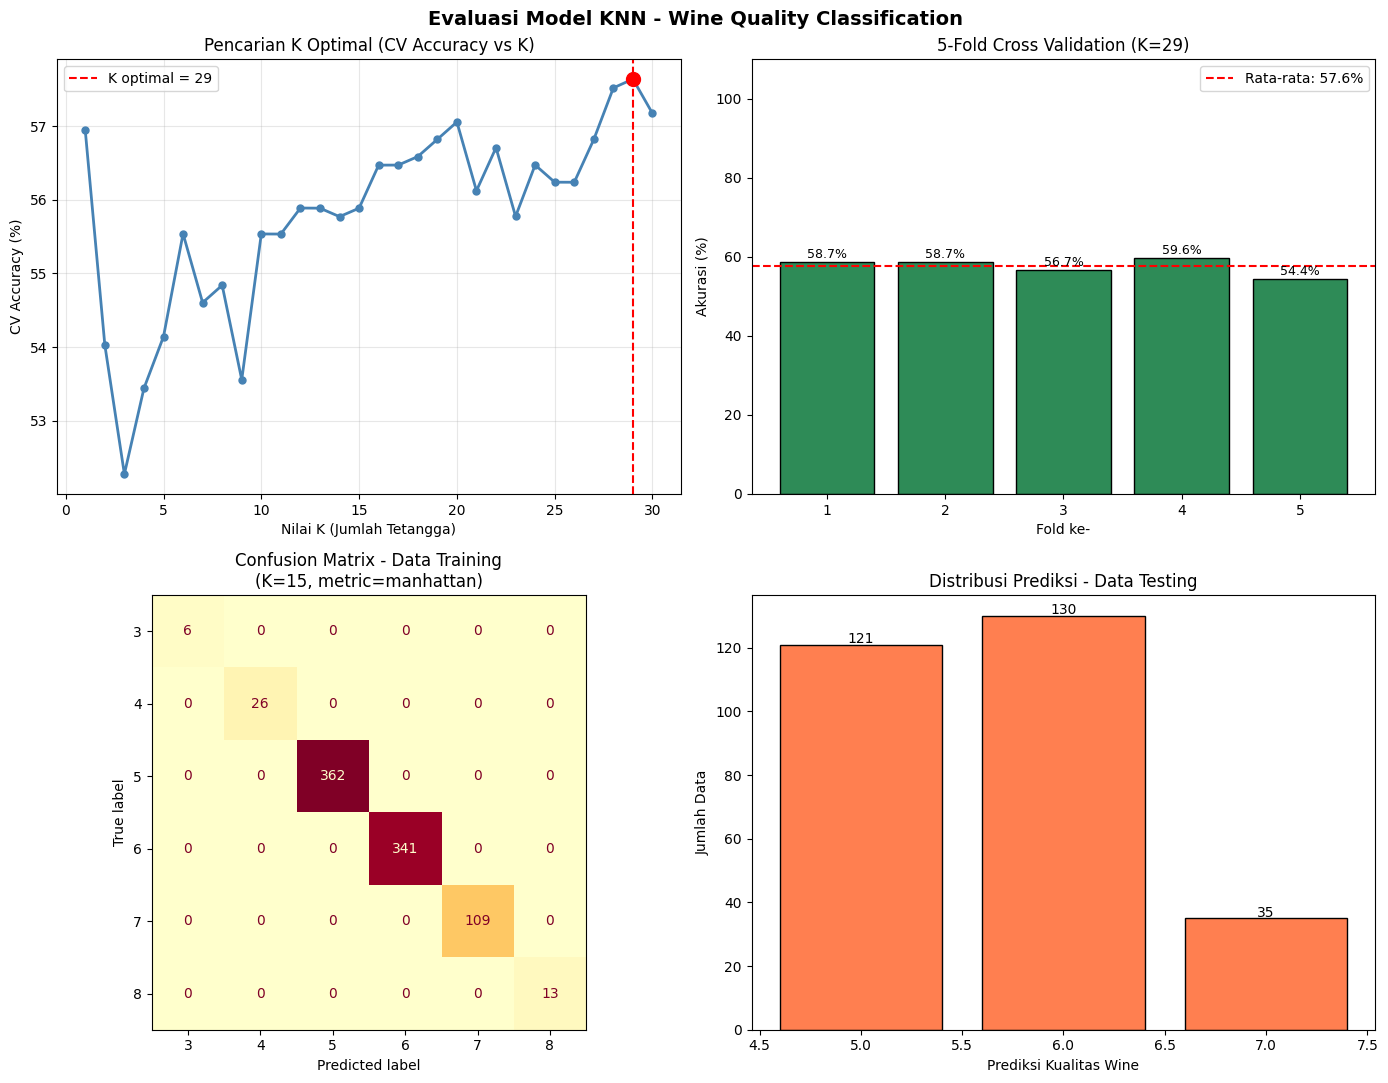


[INFO] Grafik disimpan ke 'hasil_evaluasi_knn.png'
✅ Semua proses selesai!
   - Best K         : 15
   - Best metric    : manhattan
   - Best weights   : distance
   - CV Accuracy    : 63.59%
   - File prediksi  : hasil_prediksi_knn.csv


In [ ]:
# ─────────────────────────────────────────
# 11. VISUALISASI
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Evaluasi Model KNN - Wine Quality Classification",
             fontsize=14, fontweight='bold')

# Plot 1: Nilai K vs CV Accuracy
axes[0, 0].plot(k_range, [s * 100 for s in k_scores],
                marker='o', color='steelblue', linewidth=2, markersize=5)
axes[0, 0].axvline(x=best_k, color='red', linestyle='--',
                    label=f'K optimal = {best_k}')
axes[0, 0].scatter([best_k], [best_k_acc * 100], color='red', s=100, zorder=5)
axes[0, 0].set_xlabel("Nilai K (Jumlah Tetangga)")
axes[0, 0].set_ylabel("CV Accuracy (%)")
axes[0, 0].set_title("Pencarian K Optimal (CV Accuracy vs K)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Cross Validation Score (K optimal)
axes[0, 1].bar(range(1, 6), cv_scores * 100, color='seagreen', edgecolor='black')
axes[0, 1].axhline(y=cv_scores.mean() * 100, color='red', linestyle='--',
                    label=f'Rata-rata: {cv_scores.mean()*100:.1f}%')
axes[0, 1].set_xlabel("Fold ke-")
axes[0, 1].set_ylabel("Akurasi (%)")
axes[0, 1].set_title(f"5-Fold Cross Validation (K={best_k})")
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 110)
for i, v in enumerate(cv_scores):
    axes[0, 1].text(i + 1, v * 100 + 1, f"{v*100:.1f}%", ha='center', fontsize=9)

# Plot 3: Confusion Matrix (model terbaik)
cm = confusion_matrix(y_train, y_train_pred_best, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(ax=axes[1, 0], colorbar=False, cmap='YlOrRd')
axes[1, 0].set_title(f"Confusion Matrix - Data Training\n(K={best_params['n_neighbors']}, metric={best_params['metric']})")

# Plot 4: Distribusi Prediksi Testing
pred_counts = pd.Series(y_test_pred).value_counts().sort_index()
bars = axes[1, 1].bar(pred_counts.index, pred_counts.values,
                      color='coral', edgecolor='black')
axes[1, 1].set_xlabel("Prediksi Kualitas Wine")
axes[1, 1].set_ylabel("Jumlah Data")
axes[1, 1].set_title("Distribusi Prediksi - Data Testing")
for bar, val in zip(bars, pred_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("hasil_evaluasi_knn.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n[INFO] Grafik disimpan ke 'hasil_evaluasi_knn.png'")

print("✅ Semua proses selesai!")
print(f"   - Best K         : {best_params['n_neighbors']}")
print(f"   - Best metric    : {best_params['metric']}")
print(f"   - Best weights   : {best_params['weights']}")
print(f"   - CV Accuracy    : {best_cv * 100:.2f}%")
print(f"   - File prediksi  : {output_csv}")